Scratch Jupyter Noteboook

In [1]:
import numpy as np
from numpy.typing import NDArray
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
import tqdm
import nonlinear_approximator as na
from scipy.stats import qmc
import torchvision
import os
import tempfile

import numba
import time

%matplotlib inline

In [2]:
@numba.jit
def tent(x, mu=1.99):
    return mu * np.minimum(x, 1 - x)

@numba.jit
def compute_activations(neurons, input_x, activations):
    num_samples, depth, width = activations.shape
    
    for idx_sample in range(num_samples):
        for idx_layer in range(depth):
            if idx_layer == 0:
                sample =  input_x[idx_sample, :]
                activations[idx_sample, idx_layer, :] = .5*(sample+1).T @ neurons / (28**2)
            else:
                activations[idx_sample, idx_layer, :] = tent( 
                    activations[idx_sample, idx_layer - 1, :],
                )
    return activations.reshape((num_samples, depth * width))


def gen_neurons(dimension, number):
    sampler = qmc.LatinHypercube(d=dimension)
    sample = sampler.random(n=number)
    return sample


def to_numpy_arr(img) -> NDArray[np.floating]:
    arr = np.asarray(img).flatten()
    arr = arr / 255 # 0 --> 1
    arr = arr - .5  # -.5 --> .5
    arr = 2 * arr   # -1 --> 1
    return arr



In [3]:
train_data = torchvision.datasets.MNIST(root='./data', download=True, train=True, transform=to_numpy_arr)
test_data = torchvision.datasets.MNIST(root='./data', download=True, train=False, transform=to_numpy_arr)
imgs_train, labels_train = zip(*train_data)

imgs_train = np.array(imgs_train)
labels_train = np.array(labels_train)

imgs_test, labels_test = zip(*test_data)
imgs_test = np.array(imgs_test)
labels_test = np.array(labels_test)


config = na.params.RegressionParams(
    width=3000,
    depth=25,
    input_dimension=28**2,
    transform_type=na.activations.TransformType.TENT,
    transform_params=na.params.TentParams(mu=1.99),
    output_dimension=1,
)
neurons = gen_neurons(config.input_dimension, config.width).T

In [ ]:
decoders = {}
intercepts = {}

alpha = 1e2
for idx in tqdm.tqdm(range(10)):
    with tempfile.NamedTemporaryFile('wb') as ntf:
        activations = np.memmap(
            f"activations_{idx}",
            dtype=np.float64,   # choose explicitly
            mode="w+",
            shape=(len(imgs_train), config.depth, config.width)
        )
        
        activations_train = compute_activations(
            neurons, input_x=imgs_train, activations=activations,
        )


        labels_idx_train = np.where(labels_train == idx, 1, 0)
        labels_idx_test = np.where(labels_test == idx, 1, 0)
        clf = Ridge(alpha=alpha, solver='lsqr', copy_X=False)
        clf.fit(activations_train, labels_idx_train)
        decoders[idx] = clf.coef_
        intercepts[idx] = clf.intercept_
        ntf.flush()
        ntf.close()

np.savez('decoders', decoders)
np.savez('intercepts', intercepts)


  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
accs_train = {}
accs_test = {}

activations = np.zeros((len(imgs_test), config.depth, config.width))
    
activations_test = compute_activations(
    neurons, input_x=imgs_test, activations=activations
)
for idx in range(10):
    preds_train = activations_train @ decoders[idx] + intercepts[idx]
    preds_train[preds_train >= 0.5] = True
    preds_train[preds_train < 0.5] = False
    labels_idx_train = np.where(labels_train == idx, 1, 0)
    
    preds_test = activations_test @ decoders[idx] + intercepts[idx]
    preds_test[preds_test >= 0.5] = True
    preds_test[preds_test < 0.5] = False
    labels_idx_test =  np.where(labels_test == idx, 1, 0)

    accs_train[idx] = (sum(
        preds_train == (labels_idx_train)
        ) / len(preds_train))
    
    accs_test[idx] = (sum(
        preds_test == (labels_idx_test)
        ) / len(preds_test))

: 

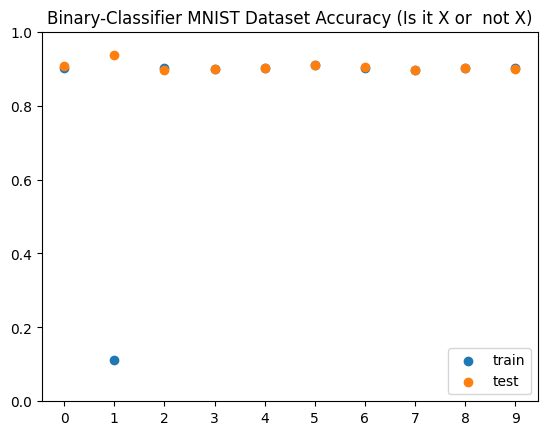

: 

In [ ]:
plt.scatter(accs_train.keys(), accs_train.values(), label='train')
plt.scatter(accs_test.keys(), accs_test.values(), label='test')
plt.legend()
plt.xticks(ticks=range(10), labels=[f"{idx}" for idx in range(10)])
plt.ylim([0, 1])
plt.title('Binary-Classifier MNIST Dataset Accuracy (Is it X or  not X)')
plt.show()


In [ ]:

preds_train = np.zeros((len(imgs_train), 10))
preds_test =  np.zeros((len(imgs_test), 10))
for idx in range(10):
    preds_train[:, idx] = activations_train @ decoders[idx] + intercepts[idx]    
    preds_test[:, idx] = activations_test @ decoders[idx] + intercepts[idx]



: 

In [ ]:
p_train_labels = preds_train.argmax(axis=-1)
p_test_labels = preds_test.argmax(axis=-1)
accs_train = p_train_labels == labels_train
accs_test = p_test_labels == labels_test
accs_train.mean(), accs_test.mean()

(np.float64(0.11236666666666667), np.float64(0.4235))

: 